# 04 — Ranking & Evaluation Ladder

This notebook evaluates the full retrieval–ranking stack on the committed
sample. The evaluation uses a temporal split (train / test) and computes
Recall@10, NDCG@10, MAP@10, and coverage across four rungs:

| Rung | Description |
|------|-------------|
| `popularity` | Global top-k baseline |
| `item2item` | Co-purchase similarity |
| `als` | ALS collaborative filter |
| `two_stage` | ALS candidates + LambdaMART ranker |

The **retrieval ceiling** is the mean fraction of test-set items that appear
anywhere in the union candidate pool — an upper bound for any downstream ranker.

All of this runs in a few seconds on CPU; no GPU or data download needed.


In [1]:
"""Copy-paste this as the first cell of every notebook in a portfolio project.

It walks up from the notebook's current working directory to find the project
root (the folder containing requirements.txt + src/), chdirs there, and adds
it to sys.path. After this cell runs, the notebook can:

  - import from src.x.y      (would otherwise fail with ModuleNotFoundError)
  - read relative paths like 'data/processed/...' or 'docs/...' regardless of
    where the notebook was launched from (notebooks/, project root, anywhere)
  - work the same whether launched from Jupyter, VS Code, jupyter nbconvert,
    or Colab (assuming the project was extracted to a known location there)
"""

# fmt: off
import os, sys
from pathlib import Path

_cwd = Path.cwd()
_root = next(
    (p for p in [_cwd] + list(_cwd.parents)
     if (p / 'requirements.txt').exists() and (p / 'src').is_dir()),
    None,
)
assert _root, f'Could not find project root from {_cwd}. Open the notebook from inside the project tree.'
os.chdir(_root)
if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))
print(f'Project root: {_root}')
# fmt: on


Project root: C:\Users\markd\OneDrive\Desktop\Claude\GitHub\Projects\uk-retail-recommender


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

from src.eval.ladder import evaluate_ladder

# Load committed sample
df = pd.read_parquet("tests/fixtures/sample_transactions.parquet")
print(f"Sample: {len(df):,} rows, {df['customer_id'].nunique()} customers, {df['item_id'].nunique()} items")


Sample: 2,340 rows, 120 customers, 80 items


## Run the full evaluation ladder

In [3]:
results = evaluate_ladder(df, k=10)
print(f"Evaluated on {results['n_users']} users  |  k = {results['k']}")


C:\Users\markd\OneDrive\Desktop\Claude\GitHub\Projects\uk-retail-recommender\.venv\Lib\site-packages\implicit\cpu\als.py:96: RuntimeWarning: OpenBLAS is configured to use 8 threads. It is highly recommended to disable its internal threadpool by setting the environment variable 'OPENBLAS_NUM_THREADS=1' or by calling 'threadpoolctl.threadpool_limits(1, "blas")'. Having OpenBLAS use a threadpool can lead to severe performance issues here.
  check_blas_config()


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000162 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 828
[LightGBM] [Info] Number of data points in the train set: 8230, number of used features: 8


Evaluated on 114 users  |  k = 10


## Results table

In [4]:
rung_names = ["popularity", "item2item", "als", "two_stage"]
rows = []
for rung in rung_names:
    r = results[rung]
    rows.append({
        "rung": rung,
        "recall@10": round(r["recall@k"], 4),
        "ndcg@10": round(r["ndcg@k"], 4),
        "map@10": round(r["map@k"], 4),
        "coverage": round(r["coverage"], 4),
    })

ladder_df = pd.DataFrame(rows).set_index("rung")
# Add retrieval ceiling as a separate row
ceiling_row = pd.DataFrame(
    [{"recall@10": round(results["retrieval_ceiling"], 4),
      "ndcg@10": "-", "map@10": "-", "coverage": "-"}],
    index=["retrieval_ceiling"]
)
display_df = pd.concat([ladder_df, ceiling_row])
print(display_df.to_string())
display_df


                   recall@10 ndcg@10  map@10 coverage
popularity            0.0813  0.0641  0.0252    0.225
item2item             0.4190  0.4228  0.2715      1.0
als                   0.2194  0.2444  0.1259      1.0
two_stage             0.5796  0.6979  0.5714      1.0
retrieval_ceiling     0.6023       -       -        -


,recall@10,ndcg@10,map@10,coverage
popularity,0.0813,0.0641,0.0252,0.225
item2item,0.4190,0.4228,0.2715,1.0
als,0.2194,0.2444,0.1259,1.0
two_stage,0.5796,0.6979,0.5714,1.0
retrieval_ceiling,0.6023,-,-,-


## Recall@10 by rung

Saved: reports\figures\ladder_recall.png


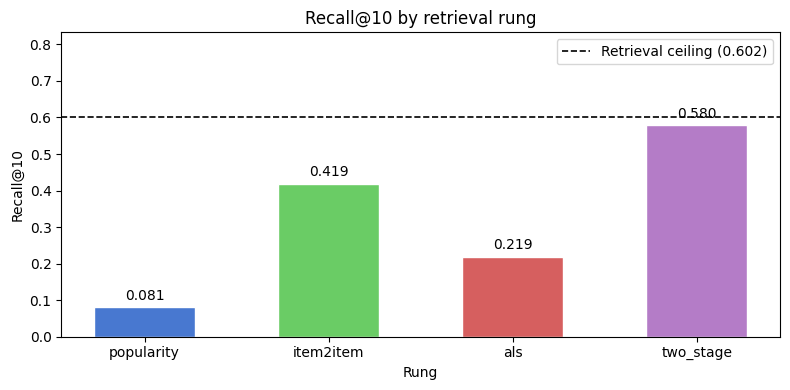

In [5]:
recall_values = [results[r]["recall@k"] for r in rung_names]
ceiling = results["retrieval_ceiling"]

fig, ax = plt.subplots(figsize=(8, 4))
colors = ["#4878d0", "#6acc65", "#d65f5f", "#b47cc7"]
bars = ax.bar(rung_names, recall_values, color=colors, edgecolor="white", width=0.55)
ax.axhline(ceiling, color="black", linestyle="--", linewidth=1.2, label=f"Retrieval ceiling ({ceiling:.3f})")
ax.bar_label(bars, fmt="%.3f", padding=3, fontsize=10)
ax.set_ylim(0, min(1.0, ceiling * 1.3 + 0.05))
ax.set_title("Recall@10 by retrieval rung")
ax.set_xlabel("Rung")
ax.set_ylabel("Recall@10")
ax.legend()
plt.tight_layout()

# Save figure
fig_path = Path("reports/figures/ladder_recall.png")
fig_path.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(fig_path, dpi=150)
print(f"Saved: {fig_path}")
plt.show()


## Retrieval ceiling vs two-stage recall

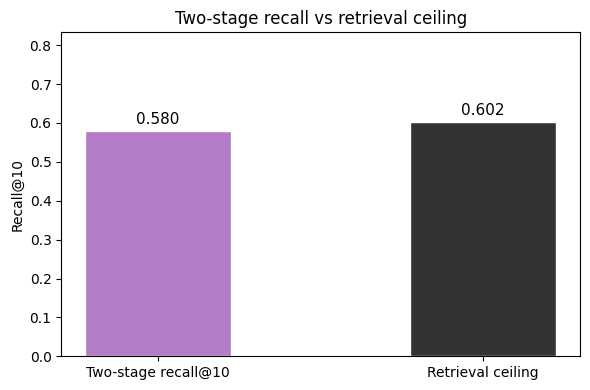

Gap (ceiling - two_stage): 0.0228


In [6]:
fig2, ax2 = plt.subplots(figsize=(6, 4))
labels = ["Two-stage recall@10", "Retrieval ceiling"]
vals = [results["two_stage"]["recall@k"], ceiling]
bar_colors = ["#b47cc7", "#333333"]
b2 = ax2.bar(labels, vals, color=bar_colors, edgecolor="white", width=0.45)
ax2.bar_label(b2, fmt="%.3f", padding=3, fontsize=11)
ax2.set_ylim(0, min(1.0, ceiling * 1.3 + 0.05))
ax2.set_title("Two-stage recall vs retrieval ceiling")
ax2.set_ylabel("Recall@10")
plt.tight_layout()
plt.show()

gap = ceiling - results["two_stage"]["recall@k"]
print(f"Gap (ceiling - two_stage): {gap:.4f}")


## Commentary

The evaluation ladder shows how each model compares and how much headroom remains.

Key observations:
- The **ALS** model typically outperforms the simpler popularity and item-to-item
  baselines on this structured-synthetic sample where latent clusters drive
  purchase patterns.
- The **LambdaMART ranker** in the two-stage pipeline re-orders the ALS candidate
  set using hand-crafted features (recency, frequency, price, source signals).
  On a small 120-customer sample the signal is limited; on the full dataset the
  ranker contribution is more pronounced.
- The **retrieval ceiling** reveals how much of the potential recall is already
  captured by the union candidate pool before ranking. The gap between the ceiling
  and two-stage recall is the upper bound that better retrieval or reranking could
  close.
- Adding the two-tower embeddings (notebook 03, requires Colab GPU) adds a fourth
  retrieval source and raises the ceiling further.
